In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [2]:
df = pd.read_csv('F:\\STEMETA_Intership_Projects\\Heart_Failure_Prediction\\heart.csv')
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [5]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

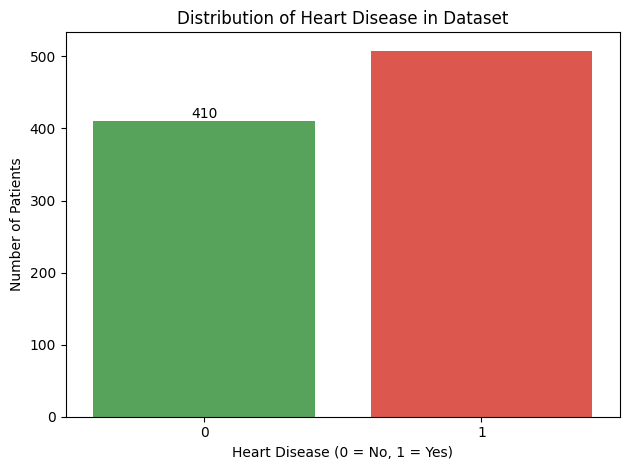

In [13]:
# Evaluating the target and finding out the potential skewness in the data
colors = ['#4CAF50', '#F44336']  # Green for no disease, Red for disease
ax = sns.countplot(x='HeartDisease', hue='HeartDisease', data=df, palette=colors, legend=False)
ax.bar_label(ax.containers[0])

plt.title("Distribution of Heart Disease in Dataset")
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.show()

In [20]:
# Label Encoding for binary features
from sklearn.preprocessing import LabelEncoder
df['Sex'] = LabelEncoder().fit_transform(df['Sex'])  # M=1, F=0
df['ExerciseAngina'] = LabelEncoder().fit_transform(df['ExerciseAngina'])
print(df.columns.tolist())

df.head()
# One-Hot Encoding for categorical columns with more than 2 categories
#df = pd.get_dummies(df, columns=['ChestPainType', 'RestingECG', 'ST_Slope'], drop_first=True)

['Age', 'Sex', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'HeartDisease', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST', 'ST_Slope_Flat', 'ST_Slope_Up']


,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up
0,40,1,140,289,0,172,0,0.0,0,True,False,False,True,False,False,True
1,49,0,160,180,0,156,0,1.0,1,False,True,False,True,False,True,False
2,37,1,130,283,0,98,0,0.0,0,True,False,False,False,True,False,True
3,48,0,138,214,0,108,1,1.5,1,False,False,False,True,False,True,False
4,54,1,150,195,0,122,0,0.0,0,False,True,False,True,False,False,True


In [21]:
# Convert all boolean (True/False) columns to 1/0
df = df.astype({col: 'int' for col in df.columns if df[col].dtype == 'bool'})
print(df.dtypes)


Age                    int64
Sex                    int64
RestingBP              int64
Cholesterol            int64
FastingBS              int64
MaxHR                  int64
ExerciseAngina         int64
Oldpeak              float64
HeartDisease           int64
ChestPainType_ATA      int64
ChestPainType_NAP      int64
ChestPainType_TA       int64
RestingECG_Normal      int64
RestingECG_ST          int64
ST_Slope_Flat          int64
ST_Slope_Up            int64
dtype: object


In [22]:
X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8586956521739131


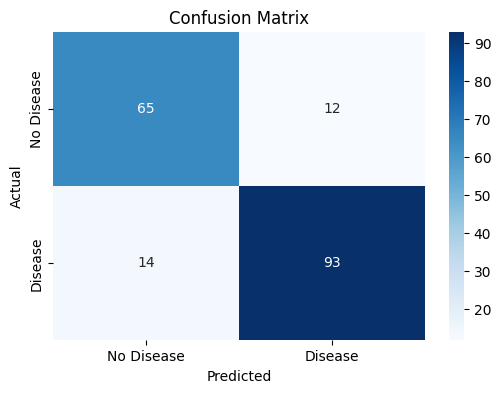

In [29]:
from sklearn.metrics import classification_report, confusion_matrix

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Plotting the Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

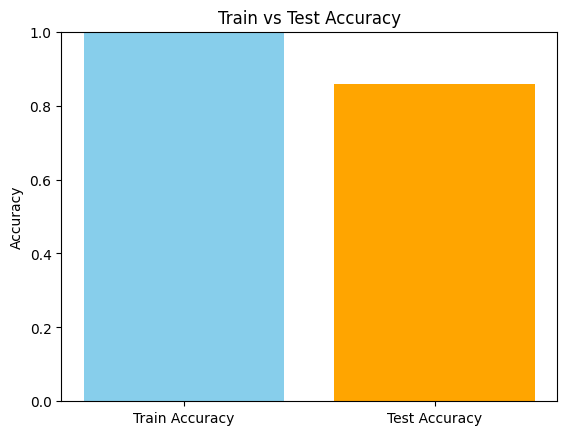

In [28]:
train_acc = accuracy_score(y_train, model.predict(X_train))
test_acc = accuracy_score(y_test, y_pred)

plt.bar(["Train Accuracy", "Test Accuracy"], [train_acc, test_acc], color=["skyblue", "orange"])
plt.ylim(0, 1)
plt.title("Train vs Test Accuracy")
plt.ylabel("Accuracy")
plt.show()


In [30]:
from catboost import CatBoostClassifier
cat_model = CatBoostClassifier(verbose=0, random_state=42)  # silent training
cat_model.fit(X_train, y_train)


In [31]:
y_pred_cat = cat_model.predict(X_test)
y_train_pred_cat = cat_model.predict(X_train)

In [32]:
train_acc = accuracy_score(y_train, y_train_pred_cat)
test_acc = accuracy_score(y_test, y_pred_cat)

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Train Accuracy: 0.9768
Test Accuracy: 0.8750


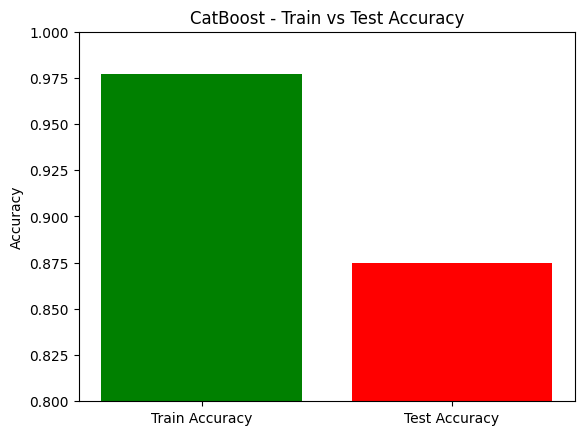

In [34]:
plt.bar(["Train Accuracy", "Test Accuracy"], [train_acc, test_acc], color=["green", "red"])
plt.ylim(0.8, 1)
plt.title("CatBoost - Train vs Test Accuracy")
plt.ylabel("Accuracy")
plt.show()


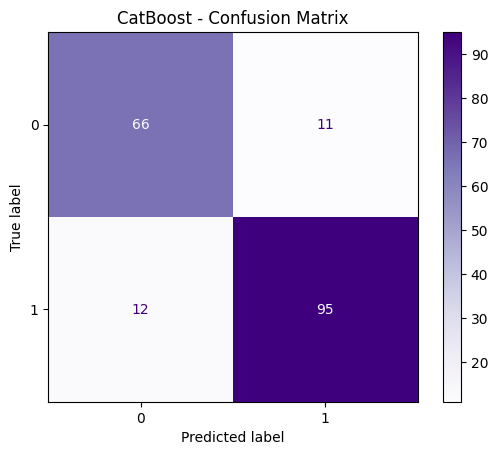

In [35]:
from sklearn.metrics import ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred_cat)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Purples')
plt.title("CatBoost - Confusion Matrix")
plt.show()


Balance the Dataset (using SMOTE)

In [49]:
feature_importances = cat_model.get_feature_importance(prettified=True)
print(feature_importances.sort_values(by='Importances', ascending=False))


           Feature Id  Importances
0             Oldpeak    13.277362
1         Cholesterol    13.088957
2       ST_Slope_Flat    11.878581
3               MaxHR    10.898550
4           RestingBP     8.505866
5                 Age     7.471019
6                 Sex     6.912116
7         ST_Slope_Up     6.536783
8      ExerciseAngina     6.022300
9   ChestPainType_NAP     5.059573
10          FastingBS     3.488053
11  ChestPainType_ATA     3.056194
12  RestingECG_Normal     1.965074
13      RestingECG_ST     1.090474
14   ChestPainType_TA     0.749099


In [50]:
# 1. Select important features FIRST
important_features = ['Oldpeak', 'Cholesterol', 'ST_Slope_Flat', 'MaxHR', 
                      'RestingBP', 'Age', 'Sex', 'ST_Slope_Up', 'ExerciseAngina']
X = df[important_features]
y = df['HeartDisease']

In [51]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# Separate features and target
X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

# Split before SMOTE (recommended)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Apply SMOTE only to the training data
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

# Check class distribution before and after
print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_bal.value_counts())


Before SMOTE: HeartDisease
1    406
0    328
Name: count, dtype: int64
After SMOTE: HeartDisease
1    406
0    406
Name: count, dtype: int64


c:\Users\Mani\anaconda3\envs\myenv\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [52]:
# Train CatBoost on balanced data
cat_model = CatBoostClassifier(verbose=0, random_state=42)
cat_model.fit(X_train_bal, y_train_bal)

In [53]:
y_Test_pred = cat_model.predict(X_test)
y_train_pred = cat_model.predict(X_train)

In [54]:
# Accuracy
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_Test_pred)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Train Accuracy: 0.9768392370572208
Test Accuracy: 0.8967391304347826


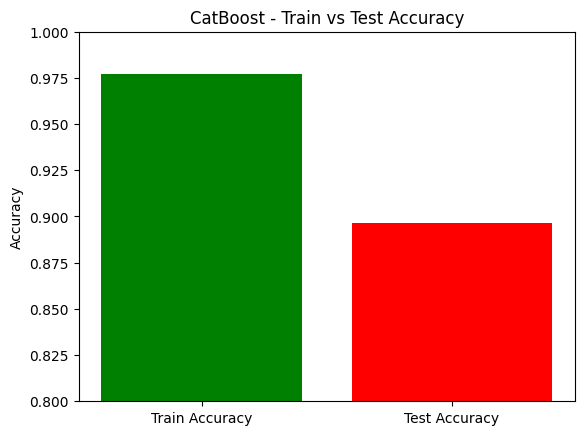

In [42]:
plt.bar(["Train Accuracy", "Test Accuracy"], [train_acc, test_acc], color=["green", "red"])
plt.ylim(0.8, 1)
plt.title("CatBoost - Train vs Test Accuracy")
plt.ylabel("Accuracy")
plt.show()